<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle

In [2]:
# Theme global
sns.set_theme(
    context='talk',   
    style='whitegrid',
    palette='Set2',    
    font='Lato',         
    rc={
        'font.size': 12,
        'axes.titlesize': 18,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Lato']
    }
)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [3]:
#Importation du fichier population.csv
DF_population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
DF_dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
DF_aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
DF_sous_nutrition = pd.read_csv('sous_nutrition.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'population.csv'

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {DF_population.shape[0]} observation(s) ou article(s)")
print(f"Le tableau comporte {DF_population.shape[1]} colonne(s)")

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(f"Le tableau comporte {DF_population.shape[1]} colonne(s)\n")
#La nature des données dans chacune des colonnes
for col, type_data in DF_population.dtypes.items():
    print(f"La colonne '{col}' est de type : {type_data}")
#Le nombre de valeurs présentes dans chacune des colonnes
comptage = DF_population.count()
print("\nNombre de valeurs dans le tableau :")
for col in DF_population.columns:
    print(f"{col:<25}{comptage[col]} valeurs")

Le tableau comporte 3 colonne(s)

La colonne 'Zone' est de type : str
La colonne 'Année' est de type : int64
La colonne 'Valeur' est de type : float64

Nombre de valeurs dans le tableau :
Zone                     1416 valeurs
Année                    1416 valeurs
Valeur                   1416 valeurs


In [ ]:
#Affichage les 5 premières lignes de la table
DF_population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
DF_population['Valeur'] = DF_population['Valeur'] * 1000

In [ ]:
#changement du nom de la colonne Valeur par Population
DF_population.rename(columns={'Valeur' : 'Population'}, inplace=True)

In [ ]:
#Affichage les 5 premières lignes de la table pour voir les modifications
DF_population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {DF_dispo_alimentaire.shape[0]} observation(s) ou article(s)")

Le tableau comporte 15605 observation(s) ou article(s)


In [ ]:
#Consulter le nombre de colonnes
print(f"Le tableau comporte {DF_dispo_alimentaire.shape[1]} colonne(s)")

Le tableau comporte 18 colonne(s)


In [ ]:
#Affichage les 5 premières lignes de la table
DF_dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols = ['Zone', 'Produit', 'Origine', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité de matière grasse en quantité (g/personne/jour)', 'Disponibilité de protéines en quantité (g/personne/jour)', 'Production', 'Importations - Quantité', 'Variation de stock', 'Exportations - Quantité', 'Disponibilité intérieure', 'Nourriture', 'Aliments pour animaux', 'Autres Utilisations', 'Semences', 'Pertes', 'Traitement']
DF_dispo_alimentaire = DF_dispo_alimentaire[cols]
DF_dispo_alimentaire.head()

,Zone,Produit,Origine,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Production,Importations - Quantité,Variation de stock,Exportations - Quantité,Disponibilité intérieure,Nourriture,Aliments pour animaux,Autres Utilisations,Semences,Pertes,Traitement
0,Afghanistan,Abats Comestible,animale,5.0,1.72,0.20,0.77,53.0,NaN,NaN,NaN,53.0,53.0,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,1.0,1.29,0.01,0.02,3.0,40.0,NaN,2.0,41.0,39.0,NaN,NaN,NaN,2.0,NaN
2,Afghanistan,Aliments pour enfants,vegetale,1.0,0.06,0.01,0.03,NaN,2.0,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,0.0,0.00,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,4.0,2.70,0.02,0.05,NaN,82.0,NaN,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#remplacement des NaN dans le dataset par des 0
DF_dispo_alimentaire.fillna(0, inplace=True)

,Zone,Produit,Origine,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Production,Importations - Quantité,Variation de stock,Exportations - Quantité,Disponibilité intérieure,Nourriture,Aliments pour animaux,Autres Utilisations,Semences,Pertes,Traitement
0,Afghanistan,Abats Comestible,animale,5.0,1.72,0.20,0.77,53.0,0.0,0.0,0.0,53.0,53.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,1.0,1.29,0.01,0.02,3.0,40.0,0.0,2.0,41.0,39.0,0.0,0.0,0.0,2.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,1.0,0.06,0.01,0.03,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,4.0,2.70,0.02,0.05,0.0,82.0,0.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,45.0,4.70,4.28,1.41,2.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
15601,Îles Salomon,Viande de Volailles,animale,11.0,3.34,0.69,1.14,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.06,0.00,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.07,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
# 1. Sélection des 9 dernières colonnes (à adapter selon ton tableau)
colonnes_a_convertir = DF_dispo_alimentaire.columns[-11:]
# 2. Conversion : Milliers de tonnes -> kg (x 1 000 000)
DF_dispo_alimentaire[colonnes_a_convertir] *= 1000000

In [ ]:
#Affichage les 5 premières lignes de la table
DF_dispo_alimentaire.head()

,Zone,Produit,Origine,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Production,Importations - Quantité,Variation de stock,Exportations - Quantité,Disponibilité intérieure,Nourriture,Aliments pour animaux,Autres Utilisations,Semences,Pertes,Traitement
0,Afghanistan,Abats Comestible,animale,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,0.0,53000000.0,53000000.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,1.0,1.29,0.01,0.02,3000000.0,40000000.0,0.0,2000000.0,41000000.0,39000000.0,0.0,0.0,0.0,2000000.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,1.0,0.06,0.01,0.03,0.0,2000000.0,0.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,4.0,2.70,0.02,0.05,0.0,82000000.0,0.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {DF_aide_alimentaire.shape[0]} observation(s) ou article(s)")

Le tableau comporte 1475 observation(s) ou article(s)


In [ ]:
#Consulter le nombre de colonnes
print(f"Le tableau comporte {DF_aide_alimentaire.shape[1]} colonne(s)")

Le tableau comporte 4 colonne(s)


In [ ]:
#Affichage les 5 premières lignes de la table
DF_aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
#changement du nom de la colonne Pays bénéficiaire par Zone
DF_aide_alimentaire = DF_aide_alimentaire.rename(columns={'Pays bénéficiaire' : 'Zone'})

In [ ]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
DF_aide_alimentaire = DF_aide_alimentaire.rename(columns={'Valeur' : 'Aide_alimentaire'})
DF_aide_alimentaire['Aide_alimentaire'] = DF_aide_alimentaire['Aide_alimentaire'] * 1000

In [ ]:
#Affichage les 5 premières lignes de la table
DF_aide_alimentaire.head()

,Zone,Année,Produit,Aide_alimentaire
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {DF_sous_nutrition.shape[0]} observation(s) ou article(s)")

Le tableau comporte 1218 observation(s) ou article(s)


In [ ]:
#Consulter le nombre de colonnes
print(f"Le tableau comporte {DF_sous_nutrition.shape[1]} colonne(s)")

Le tableau comporte 3 colonne(s)


In [ ]:
#Afficher les 5 premières lignes de la table
DF_sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
#Conversion de la colonne sous nutrition en numérique
#DF_sous_nutrition['Valeur'] = pd.to_numeric(DF_sous_nutrition['Valeur'])

In [ ]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
# Étape 1 :
DF_sous_nutrition['Valeur'] = pd.to_numeric(DF_sous_nutrition['Valeur'], errors='coerce')
# Étape 2 :
DF_sous_nutrition['Valeur'] = DF_sous_nutrition['Valeur'].fillna(0)

In [ ]:
#changement du nom de la colonne Valeur par sous_nutrition
DF_sous_nutrition.rename(columns={'Valeur' : 'Sous_nutrition'}, inplace=True)

In [ ]:
#Multiplication de la colonne sous_nutrition par 1000000
DF_sous_nutrition['Sous_nutrition'] = DF_sous_nutrition['Sous_nutrition'] * 1000000

In [ ]:
#Afficher les 5 premières lignes de la table
DF_sous_nutrition.head()

,Zone,Année,Sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
DF_population_X_nutrition = DF_population.merge(DF_sous_nutrition, on= 'Zone')
DF_population_X_nutrition_2017 = DF_population_X_nutrition[(DF_population_X_nutrition['Année_x'] == 2017) & (DF_population_X_nutrition['Année_y'] == "2016-2018")].copy()

In [ ]:
#Affichage du dataset
DF_population_X_nutrition_2017.head()

,Zone,Année_x,Population,Année_y,Sous_nutrition
28,Afghanistan,2017,36296113.0,2016-2018,10500000.0
64,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
100,Albanie,2017,2884169.0,2016-2018,100000.0
136,Algérie,2017,41389189.0,2016-2018,1300000.0
172,Allemagne,2017,82658409.0,2016-2018,0.0


In [ ]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
pop_mondiale = DF_population_X_nutrition_2017['Population'].sum()
pop_sous_nut = DF_population_X_nutrition_2017['Sous_nutrition'].sum()

ratio_sous_nut = pop_sous_nut / pop_mondiale * 100

print(f"Population mondiale en 2017 : {pop_mondiale:,.0f}".replace(',', ' '))
print(f"Population mondiale en sous nutrition en 2017 : {pop_sous_nut:,.0f}".replace(',', ' '))
print(f"En 2017 {ratio_sous_nut:.2f}% de la population mondiale etait en sous-nutrition".replace(',', ' '))

Population mondiale en 2017 : 7 543 798 779
Population mondiale en sous nutrition en 2017 : 535 700 000
En 2017 7.10% de la population mondiale etait en sous-nutrition


In [ ]:
liste_suspects = 'Chine|Brésil|Russie|États-Unis'

test = DF_sous_nutrition[DF_sous_nutrition['Année'] == '2016-2018']
aberrations = test[test['Zone'].str.contains(liste_suspects, case=False, na=False)]

print("Note : La FAO a parfois des accords de confidentialité ou des méthodes de calcul\n   différentes pour certains pays majeurs dans leurs exports publics.\n")
print(aberrations[['Zone', 'Sous_nutrition']])

Note : La FAO a parfois des accords de confidentialité ou des méthodes de calcul
   différentes pour certains pays majeurs dans leurs exports publics.

                          Zone  Sous_nutrition
166                     Brésil             0.0
226   Chine - RAS de Hong-Kong             0.0
232       Chine - RAS de Macao             0.0
238        Chine, continentale             0.0
244  Chine, Taiwan Province de        900000.0
364      États-Unis d'Amérique             0.0
376       Fédération de Russie             0.0


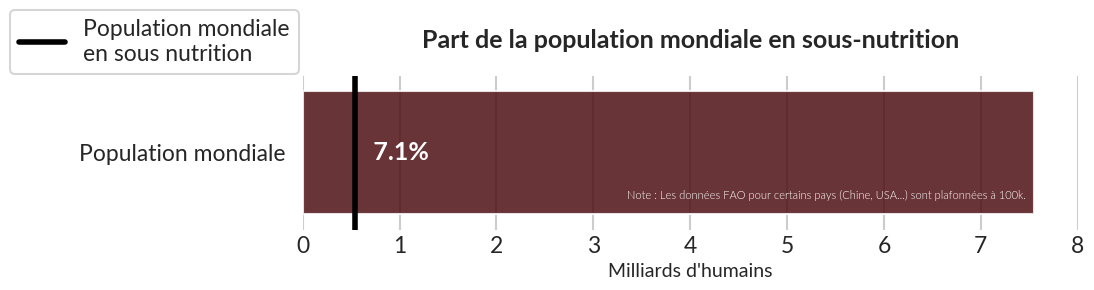

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
pop_mds = pop_mondiale / 1e9
pop_sn_mds = pop_sous_nut / 1e9
plt.figure(figsize=(10, 2))

# 2. Tracer la barre de dispo
sns.barplot(x=[pop_mds], y=["Population mondiale"], color='#5a050b', alpha=0.85)

# 3. Tracer le seuil (pop)
plt.axvline(x=pop_sn_mds, color='black', linestyle='-', linewidth=4, label='Population mondiale\nen sous nutrition')

# 4. Annotation
plt.text(pop_sn_mds, 0, f'   {ratio_sous_nut:.1f}%', va='center', fontsize=18, color='#FFFFFF', fontweight='bold')
plt.text(3.35, 0.3, "Note : Les données FAO pour certains pays (Chine, USA...) sont plafonnées à 100k.", 
            horizontalalignment='left', fontsize=8, color='white', weight='light')

# 5. Habillage
plt.title("Part de la population mondiale en sous-nutrition", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Milliards d'humains")
plt.xticks([0, 1, 2, 3, 4 , 5, 6, 7, 8])
plt.tick_params(axis='x', pad=-4)
plt.legend(bbox_to_anchor=(0.01, 1.5))

sns.despine(left=True, bottom=True)

plt.show()

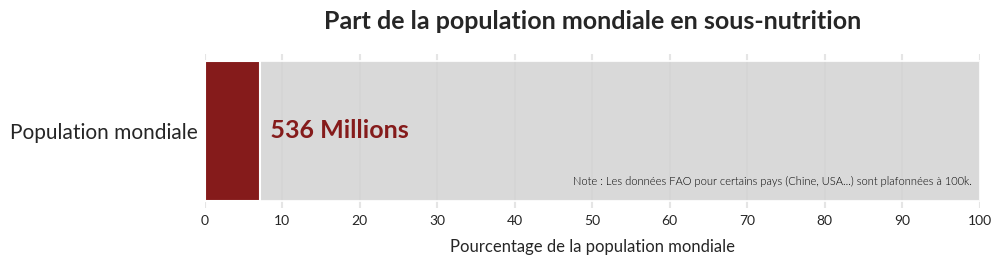

In [ ]:
# GRAPHQUE 2

# 1. Préparation du graphique
plt.figure(figsize=(10, 2))

# 2. Dessin
plt.barh(y='Population mondiale', width=100, color='#D3D3D3', alpha=0.85)
plt.barh(y='Population mondiale', width=ratio_sous_nut, color='#851B1B')

# 3. Annotation
plt.text(ratio_sous_nut -1, 0, f'   {pop_sous_nut / 1000000:.0f} Millions', va='center', fontsize=18, color='#851B1B', fontweight='bold')
plt.text(47.5, -0.31, "Note : Les données FAO pour certains pays (Chine, USA...) sont plafonnées à 100k.", 
            horizontalalignment='left', fontsize=8, color='black', weight='light')

# 4. Habillage
plt.title("Part de la population mondiale en sous-nutrition", fontsize=18, fontweight='bold', pad=18)
plt.xlabel("Pourcentage de la population mondiale", labelpad=9, fontsize=12)
plt.xticks([0, 10, 20, 30, 40 , 50, 60, 70, 80, 90, 100])
plt.tick_params(axis='x', pad=-4, labelsize=10)
plt.tick_params(axis='y', pad=-4, labelsize=15)
plt.xlim(0, 100)

sns.despine(left=True, bottom=True)
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

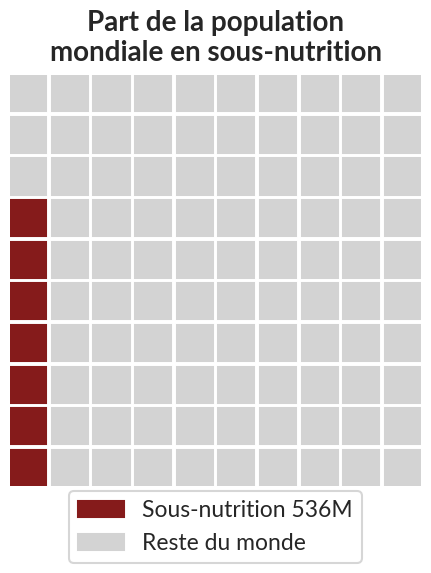

In [ ]:
# GRAPHQUE 3
# 1. Préparation du graphique
data = {f'Sous-nutrition {pop_sous_nut / 1000000:.0f}M' : ratio_sous_nut, 'Reste du monde' : 100 - ratio_sous_nut}

# 2. Dessin
plt.figure(FigureClass=Waffle, 
           rows=10, 
           columns=10, 
           values=data, 
           colors=[ '#851B1B', '#D3D3D3'],
           figsize=(6, 6),
           legend={'loc': 'lower center', 'bbox_to_anchor': (0.5, -0.215)},
           interval_ratio_x=0.15,
           interval_ratio_y=0.15
           )

# 3. Habillage
plt.title("Part de la population\nmondiale en sous-nutrition", fontsize=20, fontweight='bold', pad=10)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
#Combien mange en moyenne un être humain ? Source => https://english.elpais.com/science-tech/2022-12-19/how-many-calories-do-i-need-to-consume-per-day.html
#The World Health Organization states that a healthy adult individual should consume between 2,000 and 2,400 calories a day
calories = 2200

In [ ]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
DF_pop_2017 = DF_population[DF_population['Année'] == 2017]
DF_population_X_dispo = DF_pop_2017.merge(DF_dispo_alimentaire, on='Zone')

In [ ]:
#Affichage du nouveau dataframe
DF_population_X_dispo

,Zone,Année,Population,Produit,Origine,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Production,Importations - Quantité,Variation de stock,Exportations - Quantité,Disponibilité intérieure,Nourriture,Aliments pour animaux,Autres Utilisations,Semences,Pertes,Traitement
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,0.0,53000000.0,53000000.0,0.0,0.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,1.0,1.29,0.01,0.02,3000000.0,40000000.0,0.0,2000000.0,41000000.0,39000000.0,0.0,0.0,0.0,2000000.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,1.0,0.06,0.01,0.03,0.0,2000000.0,0.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,4.0,2.70,0.02,0.05,0.0,82000000.0,0.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,24.0,2.65,2.25,0.83,32000000.0,6000000.0,0.0,0.0,37000000.0,37000000.0,0.0,0.0,0.0,0.0,0.0
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,17.0,4.97,1.05,1.69,64000000.0,6000000.0,0.0,0.0,70000000.0,70000000.0,0.0,0.0,0.0,0.0,0.0
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,7.0,2.29,0.21,1.12,36000000.0,1000000.0,0.0,3000000.0,34000000.0,32000000.0,0.0,1000000.0,0.0,0.0,0.0
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,1.0,0.27,0.00,0.00,2000000.0,2000000.0,0.0,0.0,4000000.0,4000000.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
DF_population_X_dispo['kcal dispo'] = DF_population_X_dispo['Population'] * DF_population_X_dispo['Disponibilité alimentaire (Kcal/personne/jour)']

In [ ]:
#Calcul du nombre d'humains pouvant être nourris
nb_humain_nourris = DF_population_X_dispo['kcal dispo'].sum() / calories
print(f"Nombre d'humains potentiellement nourris : {nb_humain_nourris:,.0f}".replace(',', ' '))

print(f"La population mondiale était de {pop_mondiale:,.0f} personnes en 2017.".replace(',', ' '))
ratio_dispo = nb_humain_nourris / pop_mondiale * 100
print(f"En 2017 la disponnibilité mondiale couvrait donc {ratio_dispo:.0f}% des besoins.")

Nombre d'humains potentiellement nourris : 9 508 629 376
La population mondiale était de 7 543 798 779 personnes en 2017.
En 2017 la disponnibilité mondiale couvrait donc 126% des besoins.


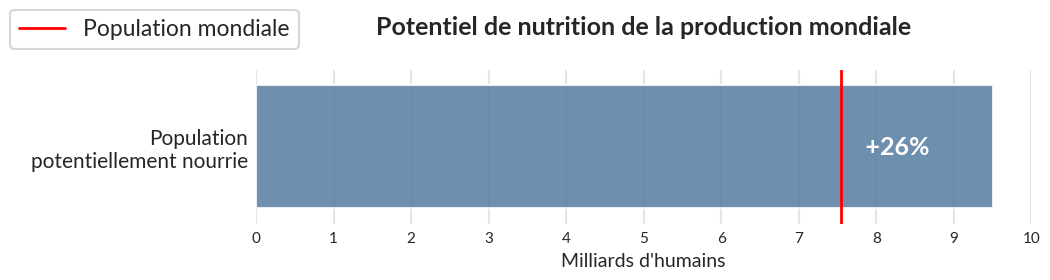

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
pop_mds = pop_mondiale / 1e9
dispo_mds = nb_humain_nourris / 1e9
plt.figure(figsize=(10, 2))

# 2. Tracer la barre de dispo
sns.barplot(x=[dispo_mds], y=["Population\npotentiellement nourrie"], color='#4a7cac', alpha=0.85)

# 3. Tracer le seuil (pop)
plt.axvline(x=pop_mds, color='red', linestyle='-', linewidth=2, label='Population mondiale')

# 4. Annotation
plt.text(pop_mds, 0, f'    {ratio_dispo - 100:+.0f}%', va='center', fontsize=18, color='#FFFFFF', fontweight='bold')

# 5. Habillage
plt.title("Potentiel de nutrition de la production mondiale", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("Milliards d'humains", labelpad=5)
plt.xticks([0, 1, 2, 3, 4 , 5, 6, 7, 8, 9, 10])
plt.tick_params(axis='x', pad=-3, labelsize=11)
plt.tick_params(axis='y', pad=-3, labelsize=15)
plt.legend(bbox_to_anchor=(0.07, 1.465))

sns.despine(left=True, bottom=True)
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
#Transfert des données avec les végétaux dans un nouveau dataframe
DF_pop_X_dispo_vegetaux = DF_population_X_dispo[DF_population_X_dispo['Origine'] == 'vegetale'].copy()

In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
DF_pop_X_dispo_vegetaux['kcal vege dispo'] = DF_pop_X_dispo_vegetaux['Population'] * DF_pop_X_dispo_vegetaux['Disponibilité alimentaire (Kcal/personne/jour)']

In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_humain_nourris_vegetaux = DF_pop_X_dispo_vegetaux['kcal vege dispo'].sum() / calories
print(f"Nombres d'humains potentiellement nourris par des vegetaux : {nb_humain_nourris_vegetaux:,.0f}".replace(',', ' '))

print(f"La population mondiale était de {pop_mondiale:,.0f} personnes en 2017.".replace(',', ' '))
ratio_dispo_vege = nb_humain_nourris_vegetaux / pop_mondiale * 100
print(f"En 2017 la disponnibilité mondiale couvrait donc {ratio_dispo_vege:.0f}% des besoins.")

Nombres d'humains potentiellement nourris par des vegetaux : 7 845 801 914
La population mondiale était de 7 543 798 779 personnes en 2017.
En 2017 la disponnibilité mondiale couvrait donc 104% des besoins.


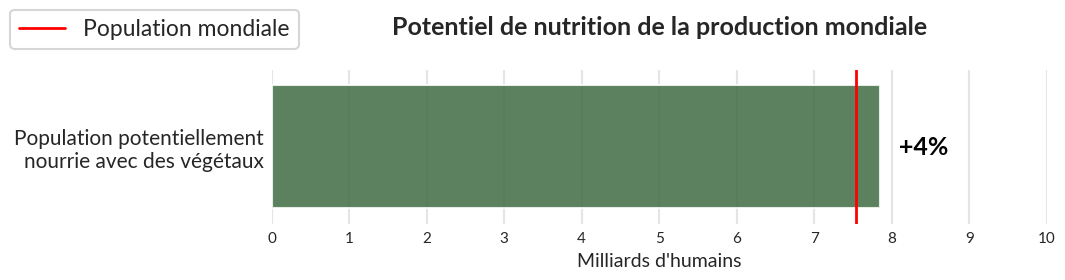

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
pop_mds = pop_mondiale / 1e9
dispo_mds = nb_humain_nourris_vegetaux / 1e9
plt.figure(figsize=(10, 2))

# 2. Tracer la barre de dispo
sns.barplot(x=[dispo_mds], y=["Population potentiellement\nnourrie avec des végétaux"], color='#37723c', alpha=0.85)

# 3. Tracer le seuil (pop)
plt.axvline(x=pop_mds, color='red', linestyle='-', linewidth=2, label='Population mondiale')

# 4. Annotation
plt.text(pop_mds, 0, f'       {ratio_dispo_vege - 100:+.0f}%', va='center', fontsize=18, color="#030303", fontweight='bold')

# 5. Habillage
plt.title("Potentiel de nutrition de la production mondiale", fontsize=18, fontweight='bold', pad=25)
plt.xlabel("Milliards d'humains", labelpad=5)
plt.xticks([0, 1, 2, 3, 4 , 5, 6, 7, 8, 9, 10])
plt.tick_params(axis='x', pad=-3, labelsize=11)
plt.tick_params(axis='y', pad=-3, labelsize=15)
plt.legend(bbox_to_anchor=(0.05, 1.465))

sns.despine(left=True, bottom=True)
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
#Calcul de la disponibilité totale
dispo_totale = DF_dispo_alimentaire['Disponibilité intérieure'].sum() / 1000000000
print(f"Dispo alimentaire mondiale : {dispo_totale:,.0f} millions de tonnes".replace(',', ' '))
mapping = {
    'Nourriture': 'Humains',
    'Traitement': 'Agro-alimentaire',
    'Aliments pour animaux': 'Animaux',
    'Autres Utilisations': 'Industrie',
    'Pertes': 'Pertes',
    'Semences': 'Semences'}
labels = []
valeurs = []
for col, nom in mapping.items():
    total_col = DF_dispo_alimentaire[col].sum() / 1000000000
    valeurs.append(total_col)
    labels.append(nom)
    ratio = total_col / dispo_totale * 100
    print(f" - Total pour {nom} : {total_col:,.0f} millions de tonnes = {ratio:.2f}%".replace(',', ' '))

Dispo alimentaire mondiale : 9 849 millions de tonnes
 - Total pour Humains : 4 876 millions de tonnes = 49.51%
 - Total pour Agro-alimentaire : 2 205 millions de tonnes = 22.38%
 - Total pour Animaux : 1 304 millions de tonnes = 13.24%
 - Total pour Industrie : 865 millions de tonnes = 8.78%
 - Total pour Pertes : 454 millions de tonnes = 4.61%
 - Total pour Semences : 155 millions de tonnes = 1.57%


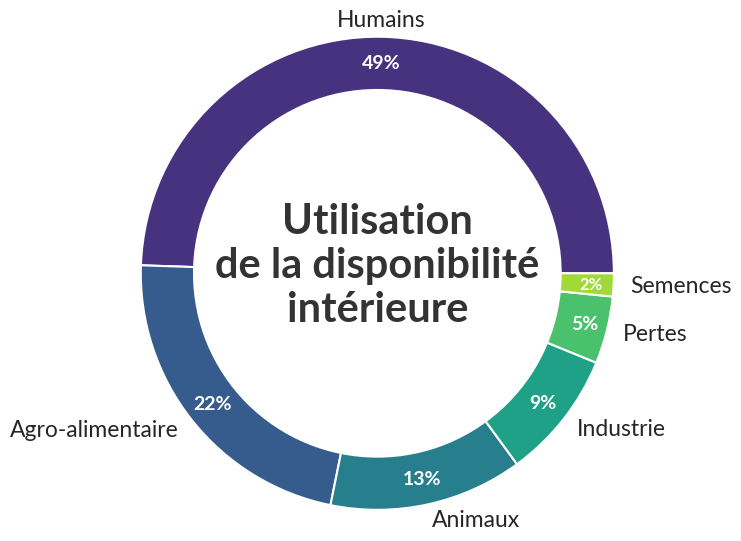

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
# plt.figure(figsize=(5, 5))
colors = sns.color_palette("viridis", len(valeurs))

# 2. Tracer le donuts
patches, texts, autotexts = plt.pie(x=valeurs, 
                                    labels=labels,
                                    radius=1.6, 
                                    colors=colors, 
                                    autopct='%.0f%%', 
                                    pctdistance=0.89,
                                    labeldistance=1.07,
                                    startangle=0)
#tracer le cercle interieur
cercle = plt.Circle((0,0), 1.24, color='white')
p = plt.gcf()
p.gca().add_artist(cercle)

# 2. La boucle pour styliser uniquement les pourcentages
for t in autotexts:
    t.set_color('white')      
    t.set_fontsize(14)         
    t.set_weight('bold')      
texts[0].set_horizontalalignment('center') #deplacement de l'index 0 (Humains) au centre

x4, y4 = autotexts[4].get_position()
autotexts[4].set_position((x4 + 0.02, y4 - 0))

x5, y5 = autotexts[5].get_position()
autotexts[5].set_fontsize(12)
autotexts[5].set_position((x5 + 0.025, y5 - 0.007))

# 3. Habillage
plt.text(0, 0.05, "Utilisation\nde la disponibilité\nintérieure", 
         ha='center', va='center', 
         fontsize=30, fontweight='bold',
         color='#333333')

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
#Création d'une liste avec toutes les variables
cereales = ['Avoine', 'Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Millet', 'Céréales, Autres', 'Seigle', 'Sorgho']

In [ ]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
DF_dispo_cereales = DF_dispo_alimentaire[DF_dispo_alimentaire['Produit'].isin(cereales)].copy()

In [ ]:
#Affichage de la proportion d'utilisation de la disponibilité de céréales
dispo_totale_céréales = DF_dispo_cereales['Disponibilité intérieure'].sum() / 1000000000
print(f"Dispo céréales mondiale : {dispo_totale_céréales:,.0f} millions de tonnes".replace(',', ' '))
mapping = {
    'Nourriture': 'Humains',
    'Aliments pour animaux': 'Animaux',
    'Autres Utilisations': 'Industrie',
    'Pertes': 'Pertes',
    'Traitement': 'Agro-alimentaire',
    'Semences': 'Semences'}
labels = []
valeurs = []
for col, nom in mapping.items():
    total_col = DF_dispo_cereales[col].sum() / 1000000000
    valeurs.append(total_col)
    labels.append(nom)
    ratio = total_col / dispo_totale_céréales * 100
    print(f" - Total pour {nom} : {total_col:,.0f} millions de tonnes = {ratio:.2f}%".replace(',', ' '))

Dispo céréales mondiale : 2 407 millions de tonnes
 - Total pour Humains : 1 029 millions de tonnes = 42.75%
 - Total pour Animaux : 874 millions de tonnes = 36.29%
 - Total pour Industrie : 235 millions de tonnes = 9.75%
 - Total pour Pertes : 107 millions de tonnes = 4.45%
 - Total pour Agro-alimentaire : 95 millions de tonnes = 3.93%
 - Total pour Semences : 69 millions de tonnes = 2.85%


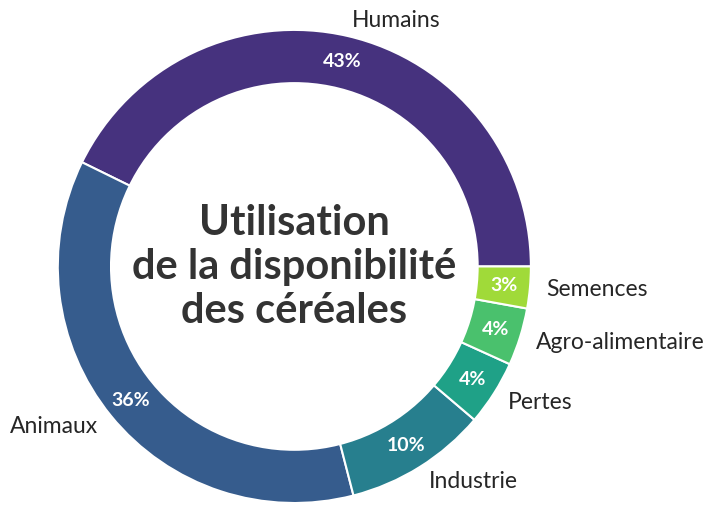

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
colors = sns.color_palette('viridis', len(valeurs))

# 2. Tracer le donuts
patches, texts, autotexts = plt.pie(x=valeurs, 
                                    labels=labels,
                                    radius=1.6, 
                                    colors=colors, 
                                    autopct='%.0f%%', 
                                    pctdistance=0.89,
                                    labeldistance=1.07,
                                    startangle=0)
#tracer le cercle interieur
cercle = plt.Circle((0,0), 1.24, color='white')
p = plt.gcf()
p.gca().add_artist(cercle)

# 3. Habillage
#La boucle pour styliser uniquement les pourcentages
for t in autotexts:
    t.set_color('white')      
    t.set_fontsize(14)         
    t.set_weight('bold')      

plt.text(0, 0, "Utilisation\nde la disponibilité\ndes céréales", 
         ha='center', va='center', 
         fontsize=30, fontweight='bold',
         color='#333333')

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
#Création de la colonne proportion par pays
DF_sous_nutrition_2017 = DF_sous_nutrition[DF_sous_nutrition['Année'] == '2016-2018']
DF_sousnut_X_pop_2017 = DF_sous_nutrition_2017.merge(DF_pop_2017, on='Zone')

DF_sousnut_X_pop_2017['%_sous_nutrition'] = DF_sousnut_X_pop_2017['Sous_nutrition'] * 100 / DF_sousnut_X_pop_2017['Population']


In [ ]:
#affichage après trie des 10 pires pays
DF_sousnut_X_pop_2017_sorted = DF_sousnut_X_pop_2017.sort_values('%_sous_nutrition', ascending=False).head(10)
DF_sousnut_X_pop_2017_sorted

,Zone,Année_x,Sous_nutrition,Année_y,Population,%_sous_nutrition
78,Haïti,2016-2018,5300000.0,2017,10982366.0,48.259182
157,République populaire démocratique de Corée,2016-2018,12000000.0,2017,25429825.0,47.188685
108,Madagascar,2016-2018,10500000.0,2017,25570512.0,41.062924
103,Libéria,2016-2018,1800000.0,2017,4702226.0,38.279742
100,Lesotho,2016-2018,800000.0,2017,2091534.0,38.249438
183,Tchad,2016-2018,5700000.0,2017,15016753.0,37.957606
161,Rwanda,2016-2018,4200000.0,2017,11980961.0,35.055619
121,Mozambique,2016-2018,9400000.0,2017,28649018.0,32.810898
186,Timor-Leste,2016-2018,400000.0,2017,1243258.0,32.173531
0,Afghanistan,2016-2018,10500000.0,2017,36296113.0,28.928718


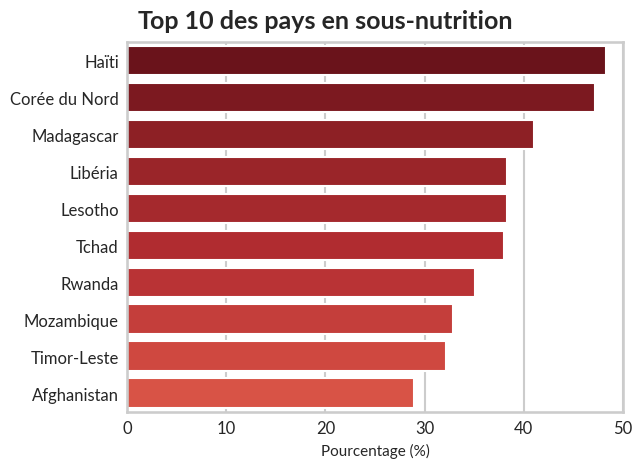

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
DF_sousnut_X_pop_2017_sorted['Zone'] = DF_sousnut_X_pop_2017_sorted['Zone'].replace({'République populaire démocratique de Corée': 'Corée du Nord'})

# 2. Dessin
palette = sns.color_palette("Reds_r", as_cmap=False, n_colors=25)[0:10]
sns.barplot(data=DF_sousnut_X_pop_2017_sorted, x='%_sous_nutrition', y='Zone', hue='Zone', palette=palette)

# 3. Habillage
plt.title("Top 10 des pays en sous-nutrition", fontweight='bold', pad=10, fontsize=18, x=0.4, ha='center')
plt.xlabel("Pourcentage (%)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=12)
plt.tick_params(axis='y', pad=-3, labelsize=12)
plt.ylabel("")
plt.xlim(0, 50)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
#calcul du total de l'aide alimentaire par pays
DF_aide_pays = DF_aide_alimentaire.groupby('Zone')[['Aide_alimentaire']].sum()

In [ ]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
DF_aide_pays_sorted = DF_aide_pays.sort_values('Aide_alimentaire', ascending=False).head(10).reset_index()
DF_aide_pays_sorted

,Zone,Aide_alimentaire
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000
5,Kenya,552836000
6,Bangladesh,348188000
7,Somalie,292678000
8,République démocratique du Congo,288502000
9,Niger,276344000


In [ ]:
aide_alim_total = DF_aide_pays['Aide_alimentaire'].sum()
top3_aide_total = DF_aide_pays_sorted['Aide_alimentaire'].head(3).sum()
ratio_top3 = top3_aide_total / aide_alim_total * 100
print(f"Les 3 pays qui ont les plus recu d'aide alimentaire entre 2013 et 2017 on recu {ratio_top3:.0f}% de l'aide alimentaire mondiale.")

Les 3 pays qui ont les plus recu d'aide alimentaire entre 2013 et 2017 on recu 40% de l'aide alimentaire mondiale.


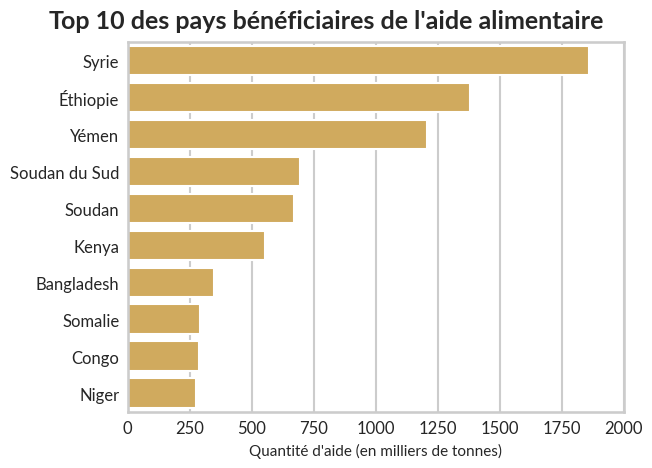

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
labels = DF_aide_pays_sorted['Zone'].replace({'République démocratique du Congo': 'Congo', 'République arabe syrienne' : 'Syrie'})
valeurs = DF_aide_pays_sorted['Aide_alimentaire'] / 1e6

# 2. Dessin
sns.barplot(x=valeurs, y=labels, color='#e3b04b')

# 3. Habillage
plt.title("Top 10 des pays bénéficiaires de l'aide alimentaire", fontweight='bold', pad=10, fontsize=18, x=0.4, ha='center')
plt.xlabel("Quantité d'aide (en milliers de tonnes)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=12)
plt.tick_params(axis='y', pad=-3, labelsize=12)
plt.ylabel("")
plt.xlim(0, 2000)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
cols = ['Zone', 'Année', 'Aide_alimentaire']
DF_evo_aide_alim = DF_aide_alimentaire[cols]
DF_evo_aide_alim = DF_evo_aide_alim.groupby(['Zone','Année']).sum().reset_index()
DF_evo_aide_alim

,Zone,Année,Aide_alimentaire
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000
...,...,...,...
223,Égypte,2013,1122000
224,Équateur,2013,1362000
225,Éthiopie,2013,591404000
226,Éthiopie,2014,586624000


In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_top5_aide = DF_aide_pays.sort_values('Aide_alimentaire', ascending=False).head(5).index.tolist()
liste_top5_aide

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [ ]:
#On filtre sur le dataframe avec notre liste
DF_evo_aide_alim = DF_evo_aide_alim[DF_evo_aide_alim['Zone'].isin(liste_top5_aide)].copy()

In [ ]:
# Affichage des pays avec l'aide alimentaire par année
DF_evo_aide_alim

,Zone,Année,Aide_alimentaire
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


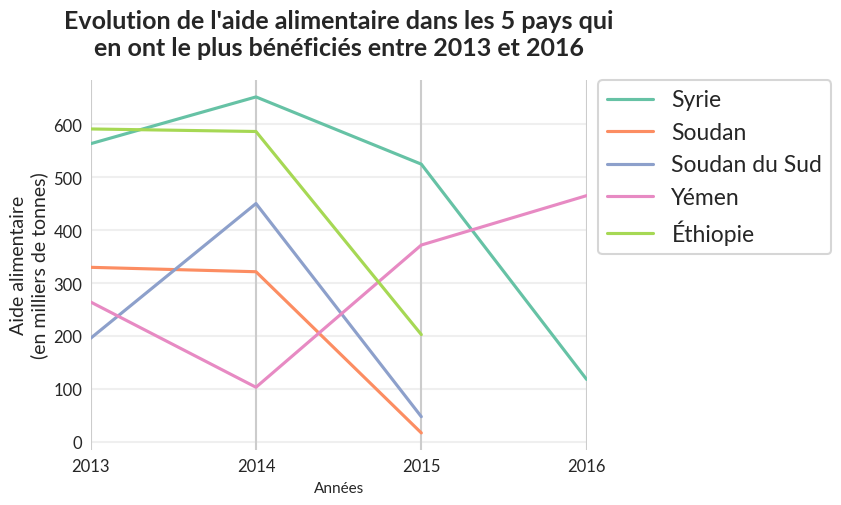

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
labels = DF_evo_aide_alim['Zone'].replace({'République arabe syrienne' : 'Syrie'})
valeurs = DF_evo_aide_alim['Aide_alimentaire'] / 1e6
DF_evo_aide_alim['Années_str'] = DF_evo_aide_alim['Année'].astype(str)

# 2. Dessin
sns.lineplot(data=DF_evo_aide_alim, x='Années_str', y=valeurs, hue=labels, errorbar=None)

# 3. Habillage
plt.title("Evolution de l'aide alimentaire dans les 5 pays qui\nen ont le plus bénéficiés entre 2013 et 2016", fontweight='bold', pad=18, fontsize=18, loc='center')
plt.xlabel("Années", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=12)
plt.tick_params(axis='y', pad=-3, labelsize=12)
plt.ylabel("Aide alimentaire\n(en milliers de tonnes)")
plt.xlim('2013', '2016')
plt.legend(bbox_to_anchor=(1, 1.03))

sns.despine(left=True, bottom=True)
plt.grid(axis='y', alpha=0.3) # Garde juste des lignes horizontales très discrètes

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_calories = DF_dispo_alimentaire.groupby('Zone')[['Disponibilité alimentaire (Kcal/personne/jour)']].sum().reset_index()

In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_calories_w10 = dispo_calories.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=True).head(10).reset_index()
dispo_calories_w10

,index,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,128,République centrafricaine,1879.0
1,166,Zambie,1924.0
2,91,Madagascar,2056.0
3,0,Afghanistan,2087.0
4,65,Haïti,2089.0
5,133,République populaire démocratique de Corée,2093.0
6,151,Tchad,2109.0
7,167,Zimbabwe,2113.0
8,114,Ouganda,2126.0
9,172,Éthiopie,2129.0


In [ ]:
moyenne_w10 = dispo_calories_w10['Disponibilité alimentaire (Kcal/personne/jour)'].mean()
ecart_moy_w10 = moyenne_w10 / calories * 100
print(f"La disponibilité alimentaire moyenne couvre {ecart_moy_w10:.0f}% du besoin calorique recommandé dans les pays les moins dotés.")

La disponibilité alimentaire moyenne couvre 94% du besoin calorique recommandé dans les pays les moins dotés.


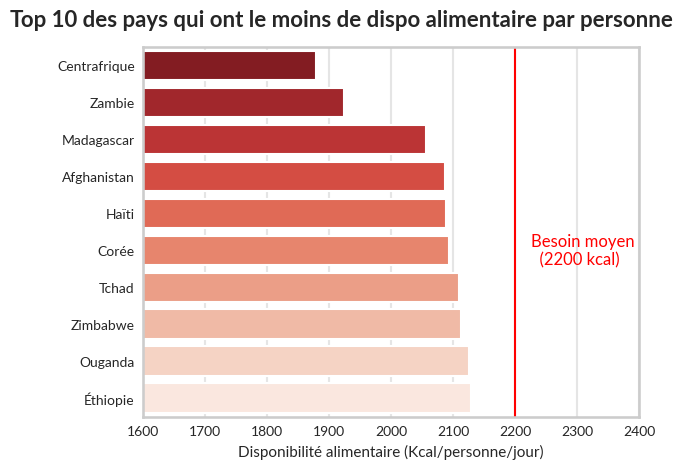

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
labels = dispo_calories_w10['Zone'].replace({'République populaire démocratique de Corée': 'Corée', 'République centrafricaine' : 'Centrafrique'})
valeurs = dispo_calories_w10['Disponibilité alimentaire (Kcal/personne/jour)']

# 2. Dessin
sns.barplot(x=valeurs, y=labels, hue=labels, palette='Reds_r')
plt.axvline(x=calories, color='red', linestyle='-', linewidth=1.5)
plt.text(calories + 25, 5, f'Besoin moyen\n  ({calories} kcal)', color='red', va='center')

# 3. Habillage
plt.title("Top 10 des pays qui ont le moins de dispo alimentaire par personne", fontweight='bold', pad=15, fontsize=16, x=0.4, ha='center')
plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=10)
plt.tick_params(axis='y', pad=-3, labelsize=10)
plt.ylabel("")
plt.xlim(1600, 2400)

plt.grid(axis='x', alpha=0.5)

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_calories_t10 = dispo_calories.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10).reset_index()
dispo_calories_t10

,index,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,11,Autriche,3770.0
1,16,Belgique,3737.0
2,159,Turquie,3708.0
3,171,États-Unis d'Amérique,3682.0
4,74,Israël,3610.0
5,72,Irlande,3602.0
6,75,Italie,3578.0
7,89,Luxembourg,3540.0
8,168,Égypte,3518.0
9,4,Allemagne,3503.0


In [ ]:
moyenne_t10 = dispo_calories_t10['Disponibilité alimentaire (Kcal/personne/jour)'].mean()
ecart_moy_t10 = calories / moyenne_t10 * 100
print(f"Les pays les mieux alimentés présentent une sur disponibilité moyenne de {ecart_moy_t10:.0f}% par rapport au besoin calorique.")

Les pays les mieux alimentés présentent une sur disponibilité moyenne de 61% par rapport au besoin calorique.


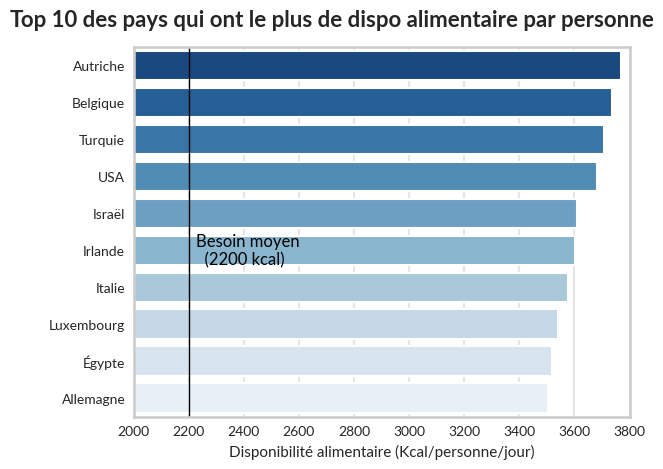

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
labels = dispo_calories_t10['Zone'].replace({"États-Unis d'Amérique": 'USA'})
valeurs = dispo_calories_t10['Disponibilité alimentaire (Kcal/personne/jour)']

# 2. Dessin
sns.barplot(x=valeurs, y=labels, hue=labels, palette='Blues_r')
plt.axvline(x=calories, color='black', linestyle='-', linewidth=1)
plt.text(calories + 25, 5, f'Besoin moyen\n  ({calories} kcal)', color='black', va='center')

# 3. Habillage
plt.title("Top 10 des pays qui ont le plus de dispo alimentaire par personne", fontweight='bold', pad=15, fontsize=16, x=0.4, ha='center')
plt.xlabel("Disponibilité alimentaire (Kcal/personne/jour)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=10)
plt.tick_params(axis='y', pad=-3, labelsize=10)
plt.ylabel("")
plt.xlim(2000, 3800)

plt.grid(axis='x', alpha=0.5)

plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Exemple de la Thaïlande pour le Manioc</h2>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande
pays_cible = 'Thaïlande'

#DF propre au pays et sur l'année 2017
DF_pop_pays = DF_population.query("Zone == @pays_cible and Année == 2017").copy()
DF_dispo_manioc = DF_dispo_alimentaire.query("Zone == @pays_cible and Produit == 'Manioc'").copy()
DF_sous_nut_pays = DF_sous_nutrition.query("Zone == @pays_cible and Année == '2016-2018'").copy()

#Nettoyage col année sur le DF sous nutrition
DF_SN_clean = DF_sous_nut_pays[['Zone', 'Sous_nutrition']].copy()

#DF Global
on = 'Zone'
how = 'inner'
DF_thailande = (
     DF_pop_pays.merge(DF_SN_clean, on=on, how=how)
                .merge(DF_dispo_manioc, on=on, how=how)
)

In [ ]:
#Calcul de la sous nutrition en Thaïlande
sn_thailande = DF_thailande['Sous_nutrition'] * 100.0 / DF_thailande['Population']
val_pop_thai = DF_thailande['Population'].iloc[0]
taux = sn_thailande.iloc[0]
nb_thai_sn = DF_thailande['Sous_nutrition'].iloc[0]
print(f"Population Thaïlandaise : {val_pop_thai:,.0f} personnes.".replace(',', ' '))
print(f"Le nombre de personnes en sous noutrition en thailande est de {nb_thai_sn:,.0f} personnes.".replace(',', ' '))
print(f"La sous nutrition en Thaïlande est de {taux:.2f}%.")

Population Thaïlandaise : 69 209 810 personnes.
Le nombre de personnes en sous noutrition en thailande est de 6 200 000 personnes.
La sous nutrition en Thaïlande est de 8.96%.


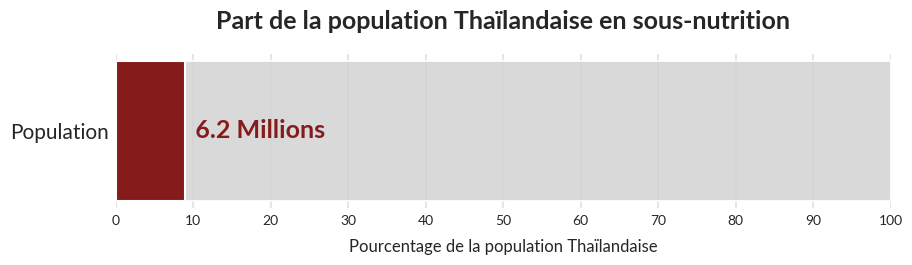

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
plt.figure(figsize=(10, 2))

# 2. Dessin
plt.barh(y='Population', width=100, color='#D3D3D3', alpha=0.85)
plt.barh(y='Population', width=taux, color='#851B1B')

# 3. Annotation
plt.text(taux -1, 0, f'   {nb_thai_sn / 1000000:.1f} Millions', va='center', fontsize=18, color='#851B1B', fontweight='bold')

# 4. Habillage
plt.title("Part de la population Thaïlandaise en sous-nutrition", fontsize=18, fontweight='bold', pad=18)
plt.xlabel("Pourcentage de la population Thaïlandaise", labelpad=9, fontsize=12)
plt.xticks([0, 10, 20, 30, 40 , 50, 60, 70, 80, 90, 100])
plt.tick_params(axis='x', pad=-4, labelsize=10)
plt.tick_params(axis='y', pad=-4, labelsize=15)
plt.xlim(0, 100)
sns.despine(left=True, bottom=True)

plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

In [ ]:
# On calcule la proportion exportée en fonction de la production
export = DF_thailande['Exportations - Quantité'].sum()
prod = DF_thailande['Production'].sum()

taux_export_thailande = export / prod * 100
print(f"Les exportations de Manioc en Thaïlande representent {taux_export_thailande:.2f}% de la production.")

Les exportations de Manioc en Thaïlande representent 83.41% de la production.


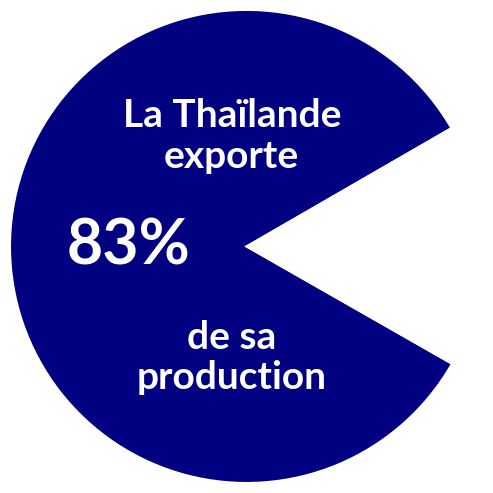

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
valeurs = [export, prod - export]
labels = ['', '']
colors = ['navy', 'white']

# 2. Tracer le donuts
plt.pie(x=valeurs, labels=labels, radius=1.6, colors=colors, labeldistance=1.1, startangle=30)

# 3. Habillage
plt.text(-0.1, 0.75, f"La Thaïlande\nexporte", 
         ha='center', va='center',  
         fontsize=28, fontweight='bold',
         color='white')
plt.text(-0.8, 0, f"{taux_export_thailande:.0f}%", 
         ha='center', va='center',  
         fontsize=45, fontweight='bold',
         color='white')
plt.text(-0.1, -0.75, f"de sa\nproduction", 
         ha='center', va='center',  
         fontsize=28, fontweight='bold',
         color='white')

plt.show()

In [ ]:
#La Thailande plus gros exportateurs de Manioc
DF_export_manioc_thai = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Exportations - Quantité', ascending=False).head(1).reset_index()
DF_export_manioc = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Exportations - Quantité', ascending=False).reset_index()

part_export_thai = DF_export_manioc_thai['Exportations - Quantité'] / DF_export_manioc['Exportations - Quantité'].sum() * 100
val_part_export_thai = part_export_thai.iloc[0]
print(f"La Thaïlande est de loin le 1er exportateur de manioc au monde avec {val_part_export_thai:.0f}% des exportations.")
export_thai_t = DF_export_manioc_thai['Exportations - Quantité'] / 1000
val_export_thai_t = export_thai_t.iloc[0]
print(f"Elle exporte {val_export_thai_t:,.0f} tonnes.".replace(',', ' '))

La Thaïlande est de loin le 1er exportateur de manioc au monde avec 70% des exportations.
Elle exporte 25 214 000 tonnes.


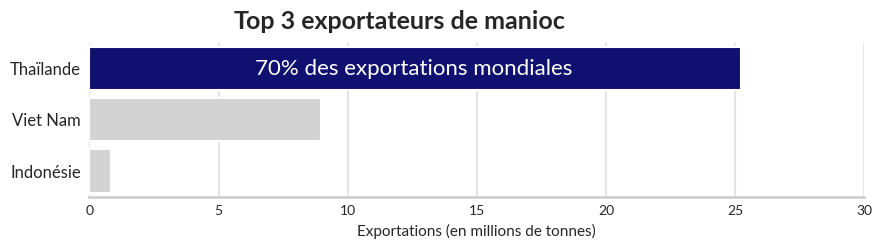

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
top_export_manioc = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Exportations - Quantité', ascending=False).head(3).reset_index()
exportations = top_export_manioc['Exportations - Quantité'] / 1e9
plt.figure(figsize=(10, 2))

# 2. Dessin
palette = ['navy' if pays == 'Thaïlande' else 'lightgrey' for pays in top_export_manioc['Zone']]
sns.barplot(data=top_export_manioc, x=exportations, y='Zone', hue='Zone', palette=palette, width=0.6, gap=-0.4)
plt.text(6.4,  0, f"{val_part_export_thai:,.0f}% des exportations mondiales", va='center', fontsize=16, color='white')

# 3. Habillage
plt.title("Top 3 exportateurs de manioc", fontweight='bold', pad=10, fontsize=18, x=0.4, ha='center')
plt.xlabel("Exportations (en millions de tonnes)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=10)
plt.tick_params(axis='y', pad=-3, labelsize=12)
plt.ylabel("")
plt.xlim(0, 30)

sns.despine(left=True)
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

In [ ]:
#analyse de la dispo en tonnes

#Prod tonnes
prod_t = prod / 1000
#Dispo interieur
dispo_manioc = DF_thailande['Disponibilité intérieure'].sum() / 1000
#Dispo nourriture
manioc_nourriture = DF_thailande['Nourriture'].sum() / 1000
conso_manioc_humain = manioc_nourriture / dispo_manioc * 100
#Dispo animaux
manioc_animaux = DF_thailande['Aliments pour animaux'].sum() / 1000
conso_manioc_animaux = manioc_animaux / dispo_manioc * 100
#Dispo agro-alimentaire
manioc_autre = DF_thailande['Autres Utilisations'].sum() / 1000
conso_manioc_autre = manioc_autre / dispo_manioc * 100
#Dispo pertes
manioc_perte = DF_thailande['Pertes'].sum() / 1000
conso_manioc_perte = manioc_perte / dispo_manioc * 100

print(f"Production de manioc : {prod_t:,.0f} tonnes".replace(',', ' '))
print(f"Les exportations de Manioc en Thaïlande representent {taux_export_thailande:.2f}% de la production.")

print(f"\nDisponibilité (Production + Importations + Stock - Exportations) : {dispo_manioc:,.0f} tonnes".replace(',', ' '))

print(f"\nConsommation de manioc pour l'alimentation humaine : {manioc_nourriture:,.0f} tonnes".replace(',', ' '))
print(f"Consommation de manioc pour l'alimentation animale : {manioc_animaux:,.0f} tonnes".replace(',', ' '))
print(f"Consommation de manioc pour l'industrie non alimentaire : {manioc_autre:,.0f} tonnes".replace(',', ' '))
print(f"Pertes de manioc : {manioc_perte:,.0f} tonnes".replace(',', ' '))

print(f"\n- {conso_manioc_humain:.2f}% de la disponibilité intérieure sert à l'alimentation humaine")
print(f"- {conso_manioc_animaux:.2f}% est dédiée à la nourriture animale")
print(f"- {conso_manioc_autre:.2f}% est destiné à l'industrie non alimentaire")
print(f"- {conso_manioc_perte:.2f}% part en pertes")

Production de manioc : 30 228 000 tonnes
Les exportations de Manioc en Thaïlande representent 83.41% de la production.

Disponibilité (Production + Importations + Stock - Exportations) : 6 264 000 tonnes

Consommation de manioc pour l'alimentation humaine : 871 000 tonnes
Consommation de manioc pour l'alimentation animale : 1 800 000 tonnes
Consommation de manioc pour l'industrie non alimentaire : 2 081 000 tonnes
Pertes de manioc : 1 511 000 tonnes

- 13.90% de la disponibilité intérieure sert à l'alimentation humaine
- 28.74% est dédiée à la nourriture animale
- 33.22% est destiné à l'industrie non alimentaire
- 24.12% part en pertes


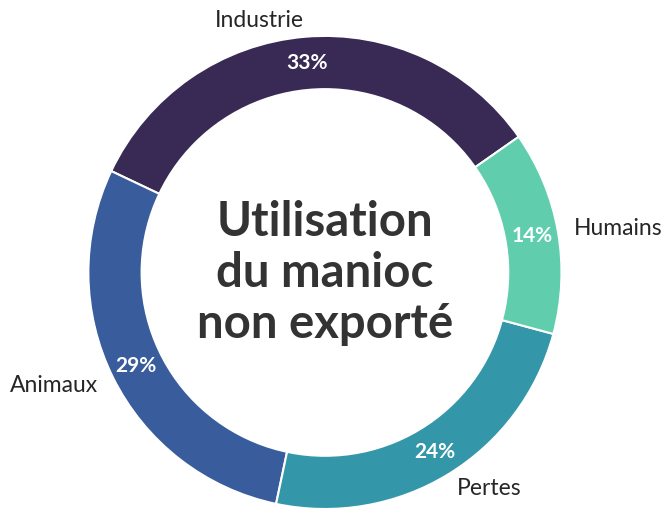

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
valeurs = [manioc_autre, manioc_animaux, manioc_perte, manioc_nourriture]
labels = ['Industrie', 'Animaux', 'Pertes', 'Humains']
colors = sns.color_palette("mako", len(valeurs))

# 2. Tracer le donuts
patches, texts, autotexts = plt.pie(x=valeurs, 
                                    labels=labels,
                                    radius=1.6, 
                                    colors=colors, 
                                    autopct='%.0f%%', 
                                    pctdistance=0.89,
                                    labeldistance=1.07,
                                    startangle=35)
#tracer le cercle interieur
cercle = plt.Circle((0,0), 1.24, color='white')
p = plt.gcf()
p.gca().add_artist(cercle)

# 3. Habillage
#boucle pour styliser uniquement les pourcentages
for t in autotexts:
    t.set_color('white')     
    t.set_fontsize(15)         
    t.set_weight('bold')      

plt.text(0, 0, "Utilisation\ndu manioc\nnon exporté", 
         ha='center', va='center', 
         fontsize=34, fontweight='bold',
         color='#333333')

plt.show()

In [ ]:
#Dispo calorique (Manioc) "Capacité Nourricière de l'Export"

#calcul du potentiel calorique du manioc
pot_calorique_manioc = DF_thailande['Disponibilité alimentaire (Kcal/personne/jour)'] / (DF_thailande['Disponibilité alimentaire en quantité (kg/personne/an)'] / 365)
val_pot_calorique = pot_calorique_manioc.iloc[0]
print(f"Sur la base des données de disponibilité réelle, on établit un ratio de {val_pot_calorique:.0f} kcal/kg de manioc.")

#Capacité Nourricière de l'Export
calories_exportées = (DF_thailande['Exportations - Quantité'] * pot_calorique_manioc) / (calories * 365)
val_cal_exp = calories_exportées.iloc[0]
print(f"Le manioc exporté par la Thaïlande pourrait nourrir {val_cal_exp:,.0f} personnes chaque année.".replace(',', ' '))

#ratio de population pouvant etre nourrit par les exportations
ratio = calories_exportées / DF_thailande['Population'] * 100
val_ratio = ratio.iloc[0]
print(f"La Thaïlande envoie à l'étranger l'équivalent de {val_ratio:.0f}% des besoins caloriques de sa propre population.")
print(f"Pour rappel le nombre de personnes en sous nutrition en thaïlande est de {nb_thai_sn:,.0f} de personnes.".replace(',', ' '))

Sur la base des données de disponibilité réelle, on établit un ratio de 1123 kcal/kg de manioc.
Le manioc exporté par la Thaïlande pourrait nourrir 35 264 336 personnes chaque année.
La Thaïlande envoie à l'étranger l'équivalent de 51% des besoins caloriques de sa propre population.
Pour rappel le nombre de personnes en sous nutrition en thaïlande est de 6 200 000 de personnes.


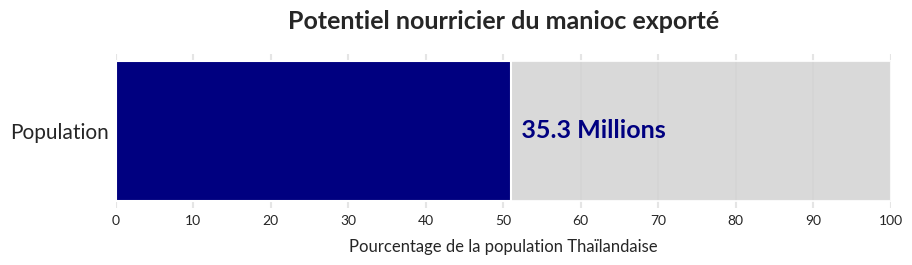

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
plt.figure(figsize=(10, 2))

# 2. Dessin
plt.barh(y='Population', width=100, color='#D3D3D3', alpha=0.85)
plt.barh(y='Population', width=val_ratio, color='navy')

# 3. Annotation
plt.text(val_ratio -1, 0, f'   {val_cal_exp / 1000000:.1f} Millions', va='center', fontsize=18, color='navy', fontweight='bold')

# 4. Habillage
plt.title("Potentiel nourricier du manioc exporté", fontsize=18, fontweight='bold', pad=18)
plt.xlabel("Pourcentage de la population Thaïlandaise", labelpad=9, fontsize=12)
plt.xticks([0, 10, 20, 30, 40 , 50, 60, 70, 80, 90, 100])
plt.tick_params(axis='x', pad=-4, labelsize=10)
plt.tick_params(axis='y', pad=-4, labelsize=15)
plt.xlim(0, 100)
sns.despine(left=True, bottom=True)

plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

In [ ]:
#A quoi servent les exportations ?

#La chine 1er importateur de manioc
DF_import_manioc_chine = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Importations - Quantité', ascending=False).head(1).reset_index()
DF_import_manioc = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Importations - Quantité', ascending=False).reset_index()

part_import_chine = DF_import_manioc_chine['Importations - Quantité'] / DF_import_manioc['Importations - Quantité'].sum() * 100
val_part_import_chine = part_import_chine.iloc[0]
print(f"La Chine est de loin le 1er importateur de manioc au monde avec {val_part_import_chine:.0f}% des importations.")

import_chine_t = DF_import_manioc_chine['Importations - Quantité'] / 1000
val_import_chine_t = import_chine_t.iloc[0]
print(f"Elle importe {val_import_chine_t:,.0f} tonnes quand la Thaïlande exporte {val_export_thai_t:,.0f} tonnes.".replace(',', ' '))
print("Note : La Thailande exporte environ 50% de sa production vers la chine.")

La Chine est de loin le 1er importateur de manioc au monde avec 76% des importations.
Elle importe 29 046 000 tonnes quand la Thaïlande exporte 25 214 000 tonnes.
Note : La Thailande exporte environ 50% de sa production vers la chine.


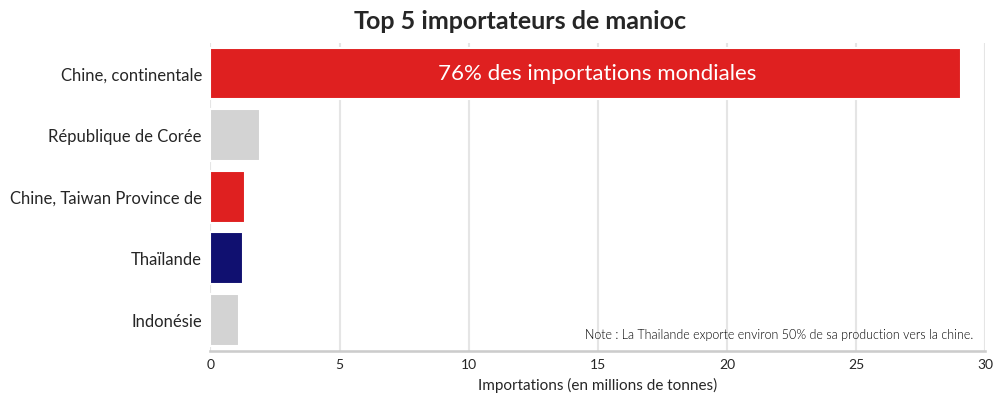

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
top_import_manioc = DF_dispo_alimentaire.query("Produit == 'Manioc'").groupby('Zone').sum().sort_values('Importations - Quantité', ascending=False).head(5).reset_index()
importations = top_import_manioc['Importations - Quantité'] / 1e9
plt.figure(figsize=(10, 4))

# 2. Dessin
palette = ['navy' if pays == 'Thaïlande' else 'red' if 'Chine' in pays else 'lightgrey' for pays in top_import_manioc['Zone']]
sns.barplot(data=top_import_manioc, x=importations, y='Zone', hue='Zone', palette=palette, width=0.6, gap=-0.4)
plt.text(8.8, 0, f"{val_part_import_chine:,.0f}% des importations mondiales", va='center', fontsize=16, color='white')
plt.text(14.5, 4.25, "Note : La Thailande exporte environ 50% de sa production vers la chine.", va='center', fontsize=9, color='black', fontweight='light')

# 3. Habillage
plt.title("Top 5 importateurs de manioc", fontweight='bold', pad=10, fontsize=18, x=0.4, ha='center')
plt.xlabel("Importations (en millions de tonnes)", fontsize=11, labelpad=5)
plt.tick_params(axis='x', pad=-3, labelsize=10)
plt.tick_params(axis='y', pad=-3, labelsize=12)
plt.ylabel("")
plt.xlim(0, 30)

sns.despine(left=True)
plt.grid(axis='y', alpha=0)
plt.grid(axis='x', alpha=0.5)

plt.show()

In [ ]:
#Utilisation du manioc en chine
#Dispo totale
dispo_totale_manioc = DF_import_manioc_chine['Disponibilité intérieure'].sum()
#Conso humaine 
proportion_manioc_humaine = DF_import_manioc_chine['Nourriture'].sum() / dispo_totale_manioc * 100
dispo_humaine_chine = DF_import_manioc_chine['Nourriture'].sum()
#Usages non alimentaires
non_alim = dispo_totale_manioc - DF_import_manioc_chine['Nourriture'].sum()
proportion_manioc_non_alim = non_alim / dispo_totale_manioc * 100
#Details non alimentaires
#Alimentation animale
proportion_manioc_animale = DF_import_manioc_chine['Aliments pour animaux'].sum() / dispo_totale_manioc * 100
#Usage industriel
proportion_manioc_industrie = DF_import_manioc_chine['Autres Utilisations'].sum() / dispo_totale_manioc * 100


print("Utilisation du manioc en Chine :")
print(f"    Part nourriture humaine : {proportion_manioc_humaine:.2f}%")
print(f"    Usages non alimentaires : {proportion_manioc_non_alim:.2f}%")
print(f"      | - Alimentation animale : {proportion_manioc_animale:.2f}%")
print(f"      | - Usage industriel : {proportion_manioc_industrie:.2f}%")

Utilisation du manioc en Chine :
    Part nourriture humaine : 7.87%
    Usages non alimentaires : 92.13%
      | - Alimentation animale : 68.08%
      | - Usage industriel : 23.64%


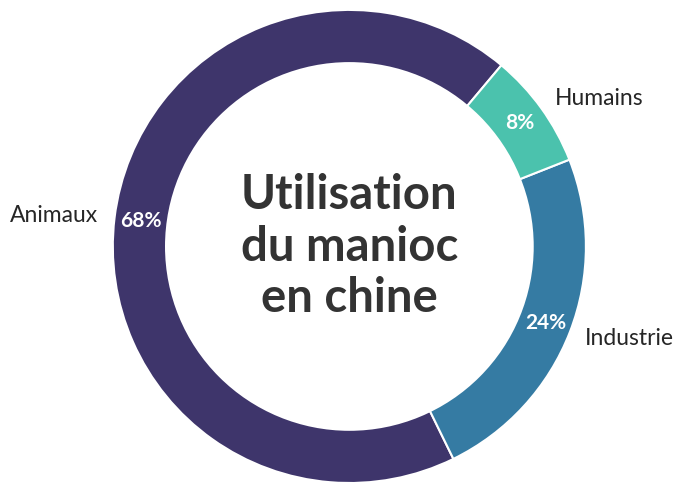

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
chine_animaux = DF_import_manioc_chine['Aliments pour animaux'].sum()
chine_indus = DF_import_manioc_chine['Autres Utilisations'].sum()
chine_bouffe = DF_import_manioc_chine['Nourriture'].sum()
valeurs = [chine_animaux, chine_indus, chine_bouffe]
labels = ['Animaux', 'Industrie',  'Humains']
colors = sns.color_palette("mako", len(valeurs))

# 2. Tracer le donuts
patches, texts, autotexts = plt.pie(x=valeurs, 
                                    labels=labels,
                                    radius=1.6, 
                                    colors=colors, 
                                    autopct='%.0f%%', 
                                    pctdistance=0.89,
                                    labeldistance=1.07,
                                    startangle=50)
#tracer le cercle interieur
cercle = plt.Circle((0,0), 1.24, color='white')
p = plt.gcf()
p.gca().add_artist(cercle)

# 3. Habillage
#boucle pour styliser uniquement les pourcentages
for t in autotexts:
    t.set_color('white')     
    t.set_fontsize(15)         
    t.set_weight('bold')      

plt.text(0, 0, "Utilisation\ndu manioc\nen chine", 
         ha='center', va='center', 
         fontsize=34, fontweight='bold',
         color='#333333')

plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyses Complémentaires</h2>
</div>

In [ ]:
# 1. On regroupe la production par pays
prod_pays = DF_population_X_dispo.groupby('Zone')[['Production']].sum().reset_index()

# 2. On fusionne avec les données de nutrition
df_final = prod_pays.merge(DF_population_X_nutrition_2017[['Zone', 'Population', 'Sous_nutrition']], on='Zone')

# 3. Calculs des colonnes (méthode standard que tu maîtrises)
df_final['Ratio_SN'] = (df_final['Sous_nutrition'] / df_final['Population']) * 100
df_final['Prod_hab'] = df_final['Production'] / df_final['Population']

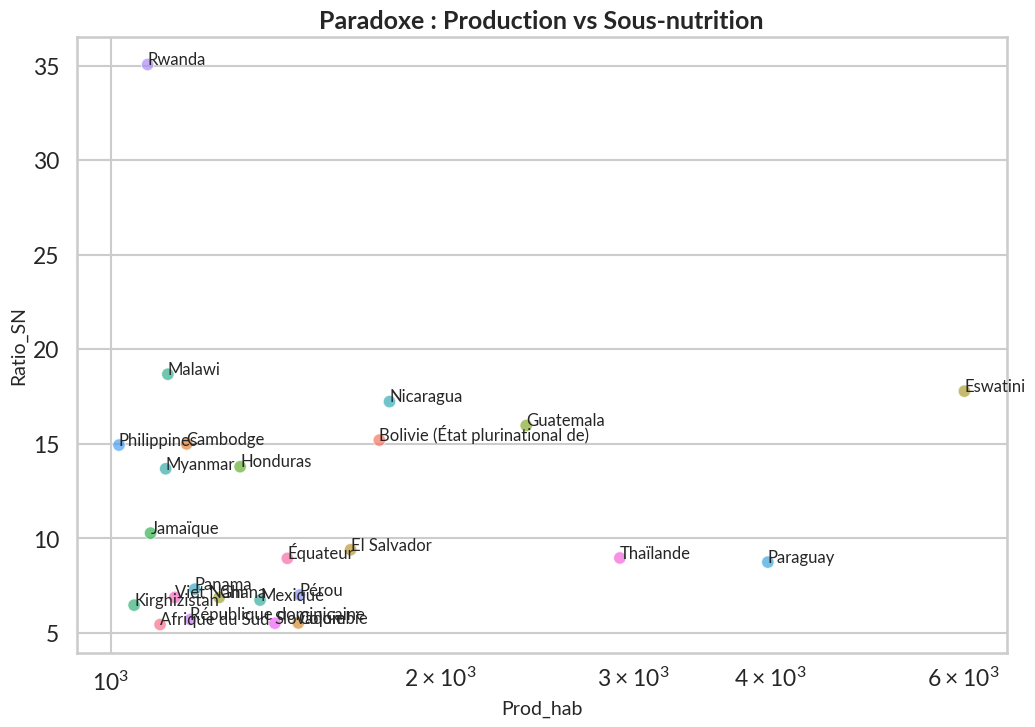

In [ ]:
# GRAPHQUE

# 1. Préparation du graphique
mediane_prod = df_final['Prod_hab'].median()
df_paradoxe = df_final.query("Sous_nutrition > 0 and Prod_hab > @mediane_prod and Ratio_SN > 5")

# 2. Dessin
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_paradoxe, x='Prod_hab', y='Ratio_SN', hue='Zone', alpha=0.7, legend=False)

# 4. Habillage : on affiche le nom seulement pour les gros producteurs avec > 5% de faim
for i in range(df_final.shape[0]):
    if (df_final.Prod_hab.iloc[i] > df_final.Prod_hab.median()) and (df_final.Ratio_SN.iloc[i] > 5):
        plt.text(df_final.Prod_hab.iloc[i], df_final.Ratio_SN.iloc[i], df_final.Zone.iloc[i])

plt.title('Paradoxe : Production vs Sous-nutrition')
plt.xscale('log') # Indispensable pour gérer les écarts de prod entre pays

plt.show()